<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

In [58]:
# Load the Iris dataset using seaborn's built-in function
df = sns.load_dataset('iris')
# Display the first 5 rows of the DataFrame
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [59]:
# Display the column names of the DataFrame
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [60]:
# Display the number of rows and columns in the DataFrame
df.shape

(150, 5)

In [61]:
# Display descriptive statistics for numerical columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [62]:
# Display a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [63]:
# Check for missing values in each column and sum them up
df.isna().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [64]:
# Separate features (X) from the target variable (Y)
X = df.drop(["species"] , axis=1) # Features: all columns except 'species'
Y = df["species"] # Target variable: 'species' column

In [65]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler to the features and transform them
X = scaler.fit_transform(X)
# Display the scaled features
X

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier , GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [67]:
# Split the dataset into training and testing sets
# 70% for training, 30% for testing
# random_state for reproducibility
# shuffle=True to ensure random distribution
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.3 , random_state=42 , shuffle=True)

# **AdaBoosting**

In [68]:
ad_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5), # Base estimator is a Decision Tree with max_depth=5
    n_estimators=100, # Number of boosting stages
    learning_rate=0.5, # Weight shrinking factor for each new estimator
    random_state=42
)

# Train the AdaBoost model on the training data
ad_model.fit(X_train , Y_train);

# Make predictions on the test set
ad_model_y_pred = ad_model.predict(X_test)

# Print evaluation metrics
print("\nAdaboost Accuracy Accuracy Score:\n" , accuracy_score(Y_test , ad_model_y_pred))
print("\nConfusion Matrix:\n" , confusion_matrix(Y_test , ad_model_y_pred))
print("\nClassification Report:\n" , classification_report(Y_test , ad_model_y_pred))


Adaboost Accuracy Accuracy Score:
 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# **GradientBoosting**

In [69]:
grad_model = GradientBoostingClassifier(
    n_estimators = 100, # Number of boosting stages
    random_state=42,
    learning_rate=0.7, # Step size shrinkage to prevent overfitting
    max_depth=20 # Maximum depth of the individual regression estimators
)

# Train the GradientBoosting model on the training data
grad_model.fit(X_train , Y_train);

# Make predictions on the test set
grad_model_y_pred = grad_model.predict(X_test)

# Print evaluation metrics
print("\nGradientBoosting Accuracy Accuracy Score:\n" , accuracy_score(Y_test , grad_model_y_pred))
print("\nConfusion Matrix:\n" , confusion_matrix(Y_test , grad_model_y_pred))
print("\nClassification Report:\n" , classification_report(Y_test , grad_model_y_pred))


GradientBoosting Accuracy Accuracy Score:
 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# **XGBoosting**

In [70]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode Y_train and Y_test into numerical labels, as XGBoost prefers numerical targets
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test) # Use transform for consistency with original Y_test

xg_model = XGBClassifier(
    n_estimators = 100, # Number of boosting rounds (trees)
    random_state=42,
    learning_rate=0.1, # Step size shrinkage to prevent overfitting
    max_depth=20, # Maximum depth of a tree
    use_label_encoder=False, # Suppress deprecation warning
    eval_metric="mlogloss" # Evaluation metric for multiclass classification
)

# Fit the XGBoost model with encoded training labels
xg_model.fit(X_train , Y_train_encoded);

# Make predictions on the test set (encoded labels)
xg_model_y_pred_encoded = xg_model.predict(X_test)
# Inverse transform predictions to original string labels for comparison
xg_model_y_pred = label_encoder.inverse_transform(xg_model_y_pred_encoded)

# Print evaluation metrics
print("\nXGBoosting Accuracy Accuracy Score:\n" , accuracy_score(Y_test , xg_model_y_pred))
print("\nConfusion Matrix:\n" , confusion_matrix(Y_test , xg_model_y_pred))
print("\nClassification Report:\n" , classification_report(Y_test , xg_model_y_pred))


XGBoosting Accuracy Accuracy Score:
 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# **Tuning of Models**

In [71]:
from sklearn.model_selection import GridSearchCV , cross_val_score

In [72]:
# Reload the dataset for tuning and visualization purposes
df = sns.load_dataset("iris")

# Separate features (X) and target (Y)
X = df.drop(["species"] , axis=1)
Y = df["species"]

# Create a subset of features (first two columns) for visualization (decision boundaries)
X_vis = df.iloc[ : ,  :2]

# Initialize LabelEncoder for target variable
le = LabelEncoder()
Y = le.fit_transform(Y) # Encode target variable to numerical labels

# Split the full dataset into training and testing sets with stratification
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.3 , random_state=42 , stratify=Y)

# Split the visualization dataset similarly (using stratification on the original Y)
Xv_test , Xv_train , _ , _ = train_test_split(X_vis , Y , test_size = 0.3 , random_state=42 , stratify=Y)

In [73]:
# Initialize AdaBoost Classifier with a Decision Tree estimator
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Initialize GradientBoosting Classifier
gb = GradientBoostingClassifier(
    n_estimators = 100,
    random_state=42,
    learning_rate=0.7,
)

# Initialize XGBoost Classifier
xgb = XGBClassifier(
    n_estimators = 100,
    random_state=42,
    learning_rate=0.7,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# Fit all models to the training data
ada.fit(X_train , Y_train);
gb.fit(X_train , Y_train);
xgb.fit(X_train , Y_train);

# **Decision Boundary Plotting**

In [74]:
def plot_decision_boundary(model , X , y , title):
  # Define the plotting boundaries based on the first two features
  x_min , x_max = X.iloc[ : , 0].min()-1 , X.iloc[ : , 0].max()+1
  y_min , y_max = X.iloc[ : , 1].min()-1 , X.iloc[ : , 1].max()+1

  # Create a meshgrid to plot the decision boundary
  xx , yy = np.meshgrid(
      np.arange(x_min , x_max , 0.02), # Generate points for x-axis
      np.arange(y_min , y_max , 0.02)  # Generate points for y-axis
  )

  # Train the model (if not already trained) on the 2-feature subset
  model.fit(X , y)
  # Predict class for each point in the meshgrid
  Z = model.predict(np.c_[xx.ravel() , yy.ravel()])
  Z = Z.reshape(xx.shape) # Reshape predictions to match meshgrid shape

  # Plot the decision boundary
  plt.figure(figsize=(5 , 4))
  plt.contourf(xx , yy , Z , alpha=0.3) # Fill contours based on predictions
  # Plot the actual data points
  plt.scatter(X.iloc[: , 0] , X.iloc[ : , 1] , c=y , edgecolors='k')
  plt.title(title) # Set plot title
  plt.show() # Display the plot

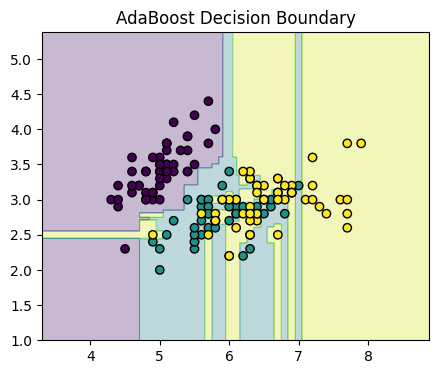

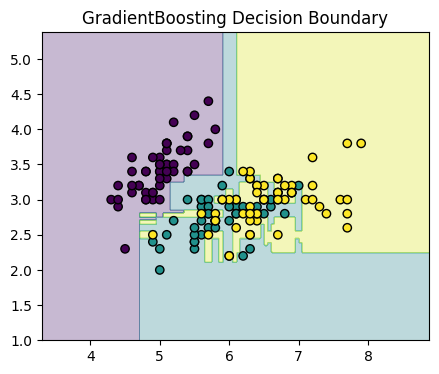

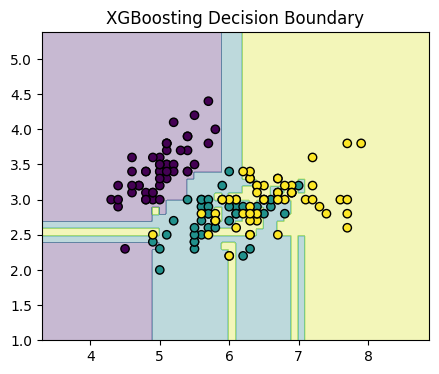

In [75]:
# Plot decision boundary for AdaBoost
plot_decision_boundary(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5)), # Create a new instance for plotting
    X_vis , Y,
    "AdaBoost Decision Boundary"
)

# Plot decision boundary for GradientBoosting
plot_decision_boundary(
    GradientBoostingClassifier(n_estimators=100 , learning_rate=0.7), # Create a new instance for plotting
    X_vis , Y ,
    "GradientBoosting Decision Boundary"
)

# Plot decision boundary for XGBoosting
plot_decision_boundary(
    XGBClassifier(n_estimators=100 , learning_rate=0.7 , use_label_encoder=False , eval_metric="mlogloss"), # Create a new instance for plotting
    X_vis , Y ,
    "XGBoosting Decision Boundary"
)

        Feature  AdaBoost  GradientBoost   XGBoost
0  sepal_length  0.014286       0.006884  0.018758
1   sepal_width  0.004762       0.016154  0.004830
2  petal_length  0.062652       0.463606  0.455443
3   petal_width  0.918301       0.513356  0.520969


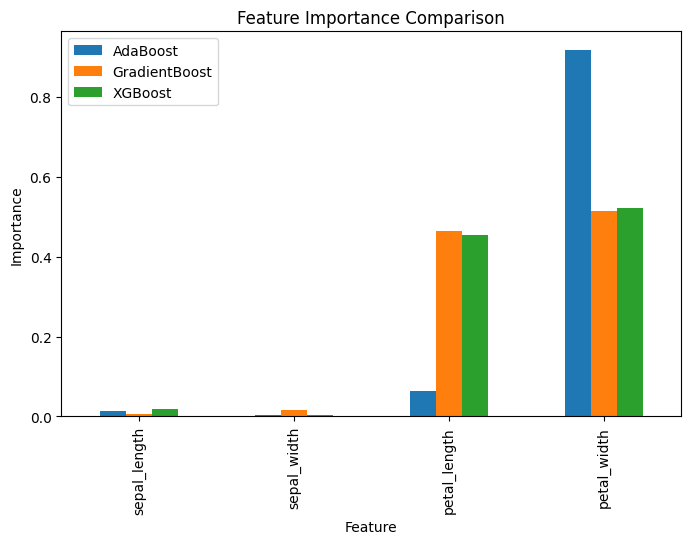

In [76]:
# Create a DataFrame to compare feature importances across models
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "AdaBoost": ada.feature_importances_,
    "GradientBoost": gb.feature_importances_,
    "XGBoost": xgb.feature_importances_
})

print(importance_df)

# Plot the feature importances
importance_df.set_index("Feature").plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance Comparison")
plt.ylabel("Importance")
plt.show()

In [77]:
# Store models in a dictionary for easy iteration
models = {
    "AdaBoost" : ada,
    "GradientBoost" : gb,
    "XGBoost" : xgb
}

# Perform 5-fold cross-validation for each model and print the mean accuracy
for name , model in models.items():
  scores = cross_val_score(model , X , Y , cv = 5)
  print(f"{name}: {scores.mean():.4f}")

AdaBoost: 0.9533
GradientBoost: 0.9600
XGBoost: 0.9467


In [78]:
# Define the parameter grid for GridSearchCV for XGBoost
param_grid = {
    "n_estimators" : [50 , 100 , 150], # Number of boosting rounds
    "learning_rate" : [0.1 , 0.5 , 1.0], # Step size shrinkage
    "max_depth" : [3 , 5 , 7], # Maximum depth of a tree
    "subsample" : [0.5 ,0.8 , 1.0] # Subsample ratio of the training instance
}

In [79]:
from sklearn.model_selection import GridSearchCV

In [80]:
# Initialize GridSearchCV with XGBoostClassifier and the defined parameter grid
grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss"
    ),
    param_grid, # Parameters to search over
    cv=5, # 5-fold cross-validation
    scoring="accuracy", # Metric to optimize
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV to the training data to find the best hyperparameters
grid.fit(X_train , Y_train)

# Print the best parameters found and the corresponding best cross-validation score
print("Best Params: " , grid.best_params_)
print("Best Score: " , grid.best_score_)

Best Params:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.5}
Best Score:  0.9523809523809523


In [81]:
# Get the best model found by GridSearchCV
best_model = grid.best_estimator_
# Make predictions on the test set using the best model
pred = best_model.predict(X_test)

# Print the accuracy of the tuned XGBoost model on the test set
print("Tuned XGBoost Accuracy:", accuracy_score(Y_test, pred))

Tuned XGBoost Accuracy: 0.9111111111111111


# **Baysian Optimization in XGBoost**

In [82]:
# Install Optuna library for Bayesian Optimization
!pip install optuna

In [83]:
import optuna

In [84]:
def objective(trial):

    # Define the hyperparameter search space using Optuna's trial object
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300), # Number of boosting rounds
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Maximum depth of a tree
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3), # Step size shrinkage
        "subsample": trial.suggest_float("subsample", 0.6, 1.0), # Subsample ratio of the training instance
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0), # Subsample ratio of columns when constructing each tree
        "gamma": trial.suggest_float("gamma", 0, 2), # Minimum loss reduction required to make a further partition
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10), # L2 regularization term on weights
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "mlogloss"
    }

    # Create an XGBoostClassifier with the suggested parameters
    model = XGBClassifier(**params)

    # Perform 5-fold cross-validation and return the mean accuracy
    score = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return score

In [85]:
# Create an Optuna study to maximize the objective function
study = optuna.create_study(direction="maximize")
# Run the optimization for 30 trials
study.optimize(objective, n_trials=30)

# Print the best parameters found and the corresponding best cross-validation score
print("Best Params:", study.best_params)
print("Best CV Score:", study.best_value)

[I 2026-03-01 16:37:47,803] A new study created in memory with name: no-name-ee668ee5-f574-414e-8926-9f4138951cb4
[I 2026-03-01 16:37:47,981] Trial 0 finished with value: 0.9523809523809523 and parameters: {'n_estimators': 77, 'max_depth': 4, 'learning_rate': 0.15866530126273554, 'subsample': 0.9314149540744971, 'colsample_bytree': 0.7631732780268843, 'gamma': 0.9875254626039975, 'reg_lambda': 8.044322062510423}. Best is trial 0 with value: 0.9523809523809523.
[I 2026-03-01 16:37:48,256] Trial 1 finished with value: 0.9523809523809523 and parameters: {'n_estimators': 133, 'max_depth': 2, 'learning_rate': 0.17486631254153517, 'subsample': 0.8374931998155755, 'colsample_bytree': 0.8349596344237176, 'gamma': 1.253962445817241, 'reg_lambda': 5.326626254957903}. Best is trial 0 with value: 0.9523809523809523.
[I 2026-03-01 16:37:48,427] Trial 2 finished with value: 0.9523809523809523 and parameters: {'n_estimators': 91, 'max_depth': 2, 'learning_rate': 0.22527425498693227, 'subsample': 0.93

Best Params: {'n_estimators': 77, 'max_depth': 4, 'learning_rate': 0.15866530126273554, 'subsample': 0.9314149540744971, 'colsample_bytree': 0.7631732780268843, 'gamma': 0.9875254626039975, 'reg_lambda': 8.044322062510423}
Best CV Score: 0.9523809523809523


In [86]:
# Initialize an XGBoostClassifier with the best hyperparameters found by Optuna
best_xgb = XGBClassifier(
    **study.best_params,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# Fit the optimized model to the training data
best_xgb.fit(X_train, Y_train)

# Make predictions on the test set using the optimized model
tuned_pred = best_xgb.predict(X_test)

# Print the accuracy of the Optuna-tuned XGBoost model on the test set
print("Tuned XGBoost Accuracy:",
      accuracy_score(Y_test, tuned_pred))

Tuned XGBoost Accuracy: 0.9111111111111111
